# Business Understanding

## Project Domain

**Healthcare / Medical Diagnostics**

Fokus pada pemanfaatan data pasien untuk mendeteksi risiko kanker serviks secara dini menggunakan pendekatan Machine Learning.

## Problem Statements

Cervical cancer merupakan salah satu penyebab utama kematian akibat kanker pada wanita, terutama di negara berkembang, karena sering terlambat terdeteksi. Meskipun banyak faktor risiko telah diketahui (misalnya: HPV, kebiasaan merokok, penggunaan kontrasepsi hormonal), proses diagnosis masih bergantung pada tes medis yang memakan waktu dan biaya.

Namun, **banyak pasien tidak rutin menjalani tes seperti Biopsi, Hinselmann, atau Sitologi** karena akses terbatas atau kesadaran yang rendah. Hal ini menyebabkan keterlambatan dalam deteksi dini dan pengobatan.

## Goals

- Mengembangkan model klasifikasi berbasis machine learning yang mampu memprediksi risiko kanker serviks berdasarkan data faktor risiko pasien.

- Memberikan alat bantu pendukung keputusan bagi tenaga medis untuk menyaring pasien berisiko tinggi.

- Meningkatkan deteksi dini dan menurunkan beban pengujian medis yang mahal bagi pasien dengan risiko rendah.

## Solution Statements

- Menggunakan dataset “Cervical Cancer Risk Classification” dari Kaggle yang berisi data faktor risiko dari pasien wanita.

- Melakukan preprocessing data: penanganan missing value, encoding, normalisasi, dan penyeimbangan kelas.

- Membangun dan melatih model Artificial Neural Network (ANN) untuk klasifikasi biner (High Risk vs Low Risk).

# Data Understanding

## Import data dari kaggle

In [29]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"yogidwiyanto","key":"6b0bb961203cba2e0f091127485264d9"}'}

In [30]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [32]:
!kaggle datasets download -d loveall/cervical-cancer-risk-classification

Dataset URL: https://www.kaggle.com/datasets/loveall/cervical-cancer-risk-classification
License(s): other


In [238]:
!mkdir cervical-cancer-risk-classification
!unzip cervical-cancer-risk-classification.zip -d cervical-cancer-risk-classification
!ls cervical-cancer-risk-classification

Archive:  cervical-cancer-risk-classification.zip
  inflating: cervical-cancer-risk-classification/kag_risk_factors_cervical_cancer.csv  
kag_risk_factors_cervical_cancer.csv


## Import Library yang dibutuhkan

In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import tensorflow as tf

In [240]:
df = pd.read_csv('cervical-cancer-risk-classification/kag_risk_factors_cervical_cancer.csv')

In [241]:
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


## Exploratory Data Analysis

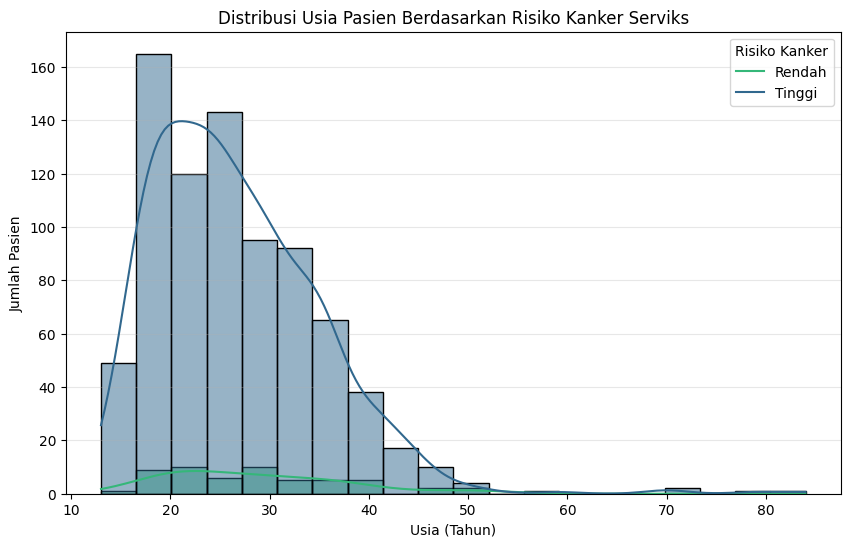

In [274]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Biopsy', bins=20, kde=True, palette='viridis')
plt.title('Distribusi Usia Pasien Berdasarkan Risiko Kanker Serviks')
plt.xlabel('Usia (Tahun)')
plt.ylabel('Jumlah Pasien')
plt.legend(['Rendah', 'Tinggi'], title='Risiko Kanker')
plt.grid(axis='y', alpha=0.3)
plt.show()

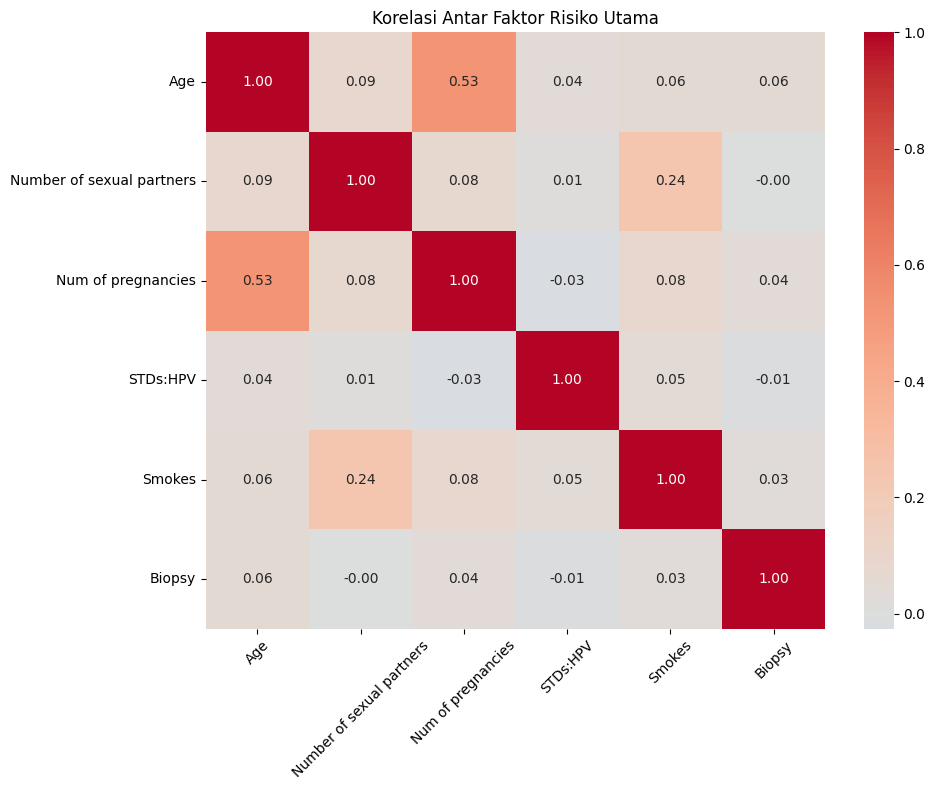

In [275]:
plt.figure(figsize=(10, 8))
corr_matrix = df[['Age', 'Number of sexual partners', 'Num of pregnancies',
                 'STDs:HPV', 'Smokes', 'Biopsy']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Korelasi Antar Faktor Risiko Utama')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-276-bc6451f208af>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Biopsy', y='Number of sexual partners', palette='Set2')


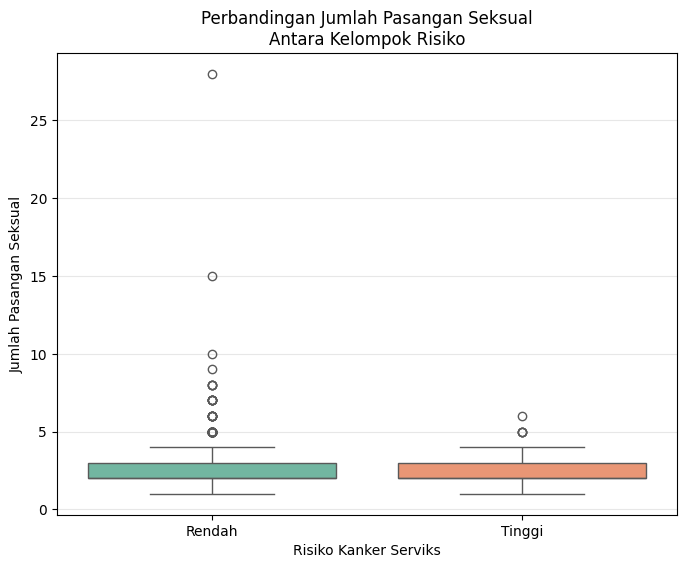

In [276]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Biopsy', y='Number of sexual partners', palette='Set2')
plt.title('Perbandingan Jumlah Pasangan Seksual\nAntara Kelompok Risiko')
plt.xlabel('Risiko Kanker Serviks')
plt.ylabel('Jumlah Pasangan Seksual')
plt.xticks([0, 1], ['Rendah', 'Tinggi'])
plt.grid(axis='y', alpha=0.3)
plt.show()

<Figure size 800x600 with 0 Axes>

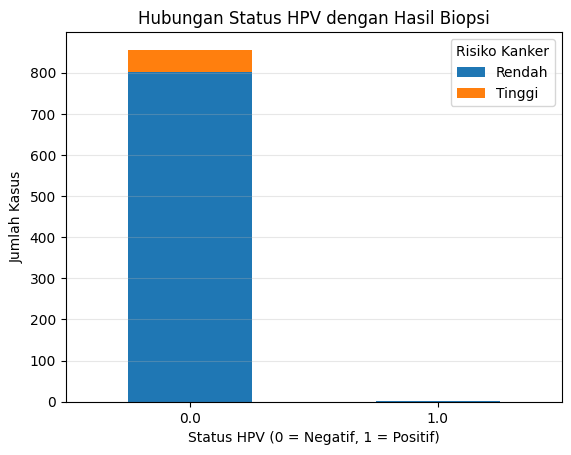

In [278]:
plt.figure(figsize=(8, 6))
pd.crosstab(df['STDs:HPV'], df['Biopsy']).plot(kind='bar', stacked=True, color=['#1f77b4','#ff7f0e'])
plt.title('Hubungan Status HPV dengan Hasil Biopsi')
plt.xlabel('Status HPV (0 = Negatif, 1 = Positif)')
plt.ylabel('Jumlah Kasus')
plt.legend(['Rendah', 'Tinggi'], title='Risiko Kanker')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.show()

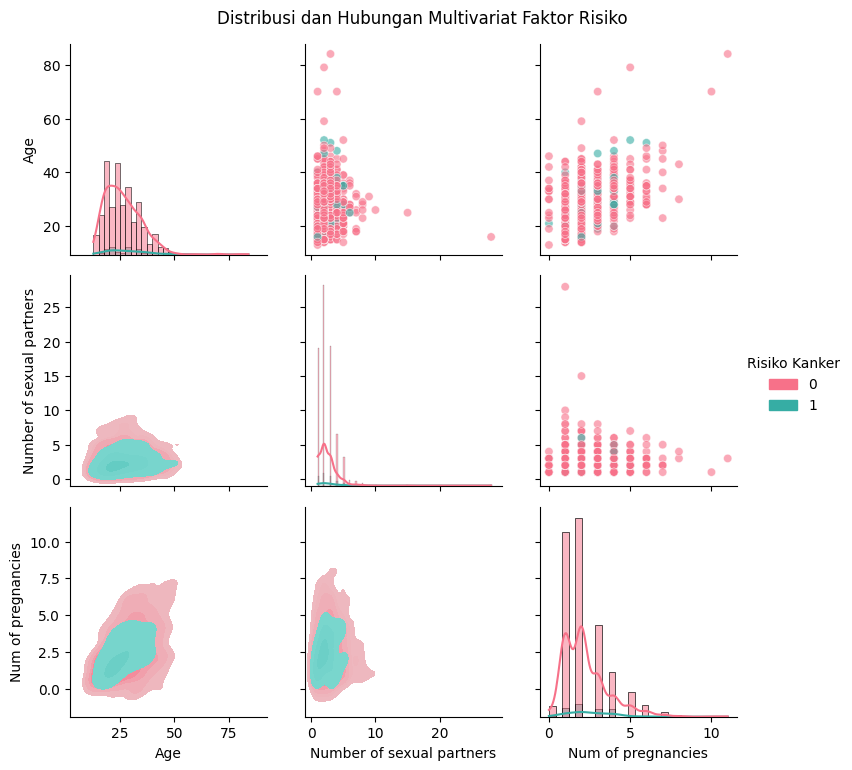

In [281]:
g = sns.PairGrid(df[['Age', 'Number of sexual partners', 'Num of pregnancies', 'Biopsy']],
                 hue='Biopsy', palette='husl')
g.map_upper(sns.scatterplot, alpha=0.6)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot, kde=True)
g.add_legend(title='Risiko Kanker')
plt.suptitle('Distribusi dan Hubungan Multivariat Faktor Risiko', y=1.02)
plt.show()

# Data Preparation

In [242]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

In [243]:
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [244]:
# Convert object columns to numeric where possible
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='ignore')

<ipython-input-244-e2444baf63c2>:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [245]:
print(df.isnull().sum())

Age                                     0
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs:condylomatosis                   105
STDs:cervical condylomatosis          105
STDs:vaginal condylomatosis           105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:AIDS                             105
STDs:HIV                              105
STDs:Hepatitis B                  

In [246]:
# Fill missing values with median for numerical columns
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

<ipython-input-246-aa510145561d>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [247]:
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0,0,0,0,0,0,0,0
2,34,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,4.0,3.0,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,4.0,3.0,0,0,0,0,0,0,0,0


In [248]:
selected_features = [
    'Age',                          # Usia → Faktor risiko utama
    'Number of sexual partners',     # Jumlah pasangan seksual → Risiko HPV
    'Num of pregnancies',            # Jumlah kehamilan → Perubahan hormonal
    'Smokes',                       # Merokok → Risiko kanker
    'Hormonal Contraceptives',       # Kontrasepsi hormonal → Risiko HPV
    'STDs',                         # Riwayat penyakit menular seksual
    'STDs:HPV',                     # Infeksi HPV → Penyebab utama kanker serviks
    'Hinselmann',                   # Hasil tes Hinselmann (indikator langsung)
    'Citology',                     # Hasil sitologi (indikator langsung)
    'Biopsy'                        # Target
]

In [249]:
df = df[selected_features]

In [250]:
# Select features and target
# Assuming 'Biopsy' is the target variable (1: cancer, 0: no cancer)
X = df.drop(['Biopsy'], axis=1)
y = df['Biopsy']

In [251]:
df.head()

,Age,Number of sexual partners,Num of pregnancies,Smokes,Hormonal Contraceptives,STDs,STDs:HPV,Hinselmann,Citology,Biopsy
0,18,4.0,1.0,0.0,0.0,0.0,0.0,0,0,0
1,15,1.0,1.0,0.0,0.0,0.0,0.0,0,0,0
2,34,1.0,1.0,0.0,0.0,0.0,0.0,0,0,0
3,52,5.0,4.0,1.0,1.0,0.0,0.0,0,0,0
4,46,3.0,4.0,0.0,1.0,0.0,0.0,0,0,0


In [252]:
# Encode categorical variables if any
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [254]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [255]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modeling

In [259]:
model = Sequential([
    Dense(32, input_dim=X_scaled.shape[1], activation='relu'),  # Input layer
    Dropout(0.3),  # Mengurangi overfitting
    Dense(16, activation='relu'),  # Hidden layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Output layer (binary classification)
])

In [260]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [261]:
# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [262]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865 (3.38 KB)

 Trainable params: 865 (3.38 KB)

 Non-trainable params: 0 (0.00 B)

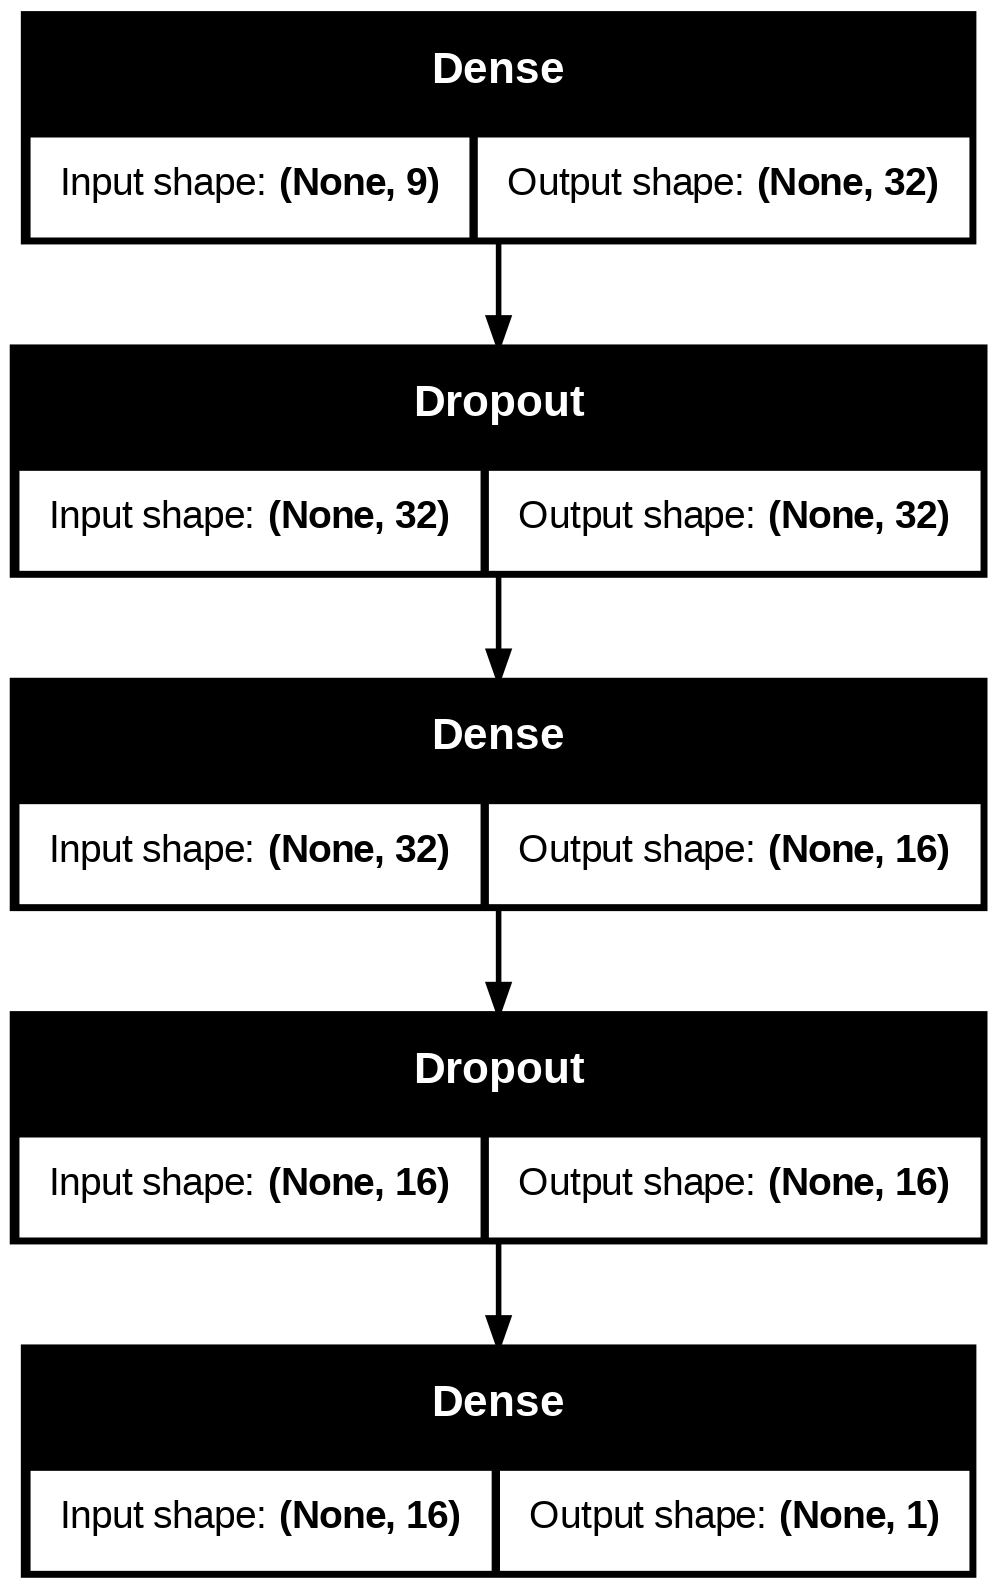

In [263]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [264]:
history = model.fit(
    X_scaled, y,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4630 - loss: 0.7807 - val_accuracy: 0.8953 - val_loss: 0.5549
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7582 - loss: 0.5731 - val_accuracy: 0.9477 - val_loss: 0.4502
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8757 - loss: 0.4742 - val_accuracy: 0.9477 - val_loss: 0.3770
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9071 - loss: 0.4168 - val_accuracy: 0.9360 - val_loss: 0.3182
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9285 - loss: 0.3567 - val_accuracy: 0.9360 - val_loss: 0.2727
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9511 - loss: 0.3021 - val_accuracy: 0.9360 - val_loss: 0.2395
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9452 - loss: 0.2385 - val_accuracy: 0.9535 - val_loss: 0.2171
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9400 - loss: 0.2387 - val_accuracy: 0.9535 - val_loss

# Evaluation

In [265]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [266]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.936046511627907

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       161
           1       0.00      0.00      0.00        11

    accuracy                           0.94       172
   macro avg       0.47      0.50      0.48       172
weighted avg       0.88      0.94      0.91       172


Confusion Matrix:
[[161   0]
 [ 11   0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [267]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Low Risk', 'High Risk']

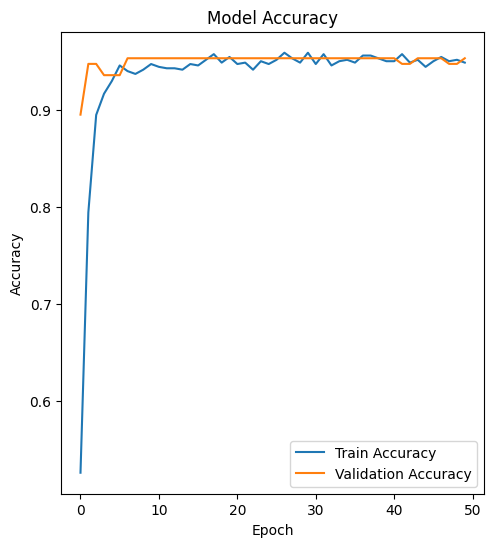

In [269]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

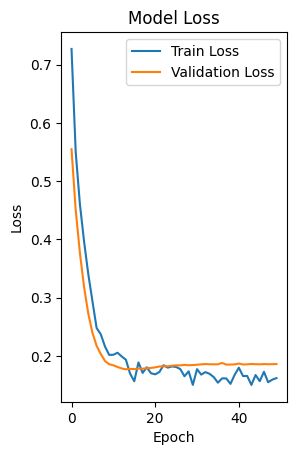

In [270]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Deployment

## Model Simulation

In [271]:
def predict_cancer_risk(new_data):
    # Define expected feature order (must match training data)
    expected_features = [
        'Age',
        'Number of sexual partners',
        'Num of pregnancies',
        'Smokes',
        'Hormonal Contraceptives',
        'STDs',
        'STDs:HPV',
        'Hinselmann',
        'Citology'
    ]

In [272]:
# Model simulation with new data (optimized for reduced features)
def predict_cancer_risk(new_data):
    # Define expected feature order (must match training data)
    expected_features = [
        'Age',
        'Number of sexual partners',
        'Num of pregnancies',
        'Smokes',
        'Hormonal Contraceptives',
        'STDs',
        'STDs:HPV',
        'Hinselmann',
        'Citology'
    ]

    # Convert input to DataFrame with correct column order
    new_data_df = pd.DataFrame([new_data], columns=expected_features)

    # Scale the features (no encoding needed as we removed categorical features)
    new_data_scaled = scaler.transform(new_data_df)

    # Make prediction
    prediction = model.predict(new_data_scaled)
    probability = prediction[0][0]

    # Return detailed response
    risk_level = "High" if probability > 0.5 else "Low"
    recommendation = "Consult a doctor immediately" if risk_level == "High" else "Regular screening recommended"

    return {
        'risk_level': risk_level,
        'probability': float(probability),
        'interpretation': f"{risk_level} risk of cervical cancer (probability: {probability:.2f})",
        'recommendation': recommendation
    }

In [273]:
# Example usage with reduced features
sample_data = {
    'Age': 45,
    'Number of sexual partners': 2,
    'Num of pregnancies': 3,
    'Smokes': 1,  # 1 = Yes, 0 = No
    'Hormonal Contraceptives': 1,  # 1 = Yes, 0 = No
    'STDs': 1,  # 1 = Yes, 0 = No
    'STDs:HPV': 1,  # 1 = HPV positive, 0 = negative
    'Hinselmann': 0,  # 0 = Negative, 1 = Positive
    'Citology': 0  # 0 = Negative, 1 = Positive
}

result = predict_cancer_risk(sample_data)
print(f"Result: {result['interpretation']}")
print(f"Recommendation: {result['recommendation']}")
print(f"Raw probability: {result['probability']:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Result: Low risk of cervical cancer (probability: 0.08)
Recommendation: Regular screening recommended
Raw probability: 0.0818


## Save Model

In [93]:
joblib.dump(label_encoders, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [94]:
import tensorflow as tf

# Save as TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('cancer_serviks_model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpc5770eh8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 9), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136707479108112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136707479107536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136707479095632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136707479096400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136707479096592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136707479106768: TensorSpec(shape=(), dtype=tf.resource, name=None)
